# Keras 전처리 레이어를 사용한 구조적 데이터 분류

[Kaggle 대회의 PetFinder 데이터세트](https://www.kaggle.com/c/petfinder-adoption-prediction)를 사용하여 구조적 데이터를 분류

목표: 반려 동물이 입양되는지 예측

In [195]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers


In [196]:
dataset_url = 'http://storage.googleapis.com/download.tensorflow.org/data/petfinder-mini.zip'
csv_file = 'datasets/petfinder_mini_extracted/petfinder-mini/petfinder-mini.csv'

tf.keras.utils.get_file('petfinder_mini.zip', dataset_url, extract=True, cache_dir='.')
dataframe = pd.read_csv(csv_file)
dataframe.head()

,Type,Age,Breed1,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,Sterilized,Health,Fee,Description,PhotoAmt,AdoptionSpeed
0,Cat,3,Tabby,Male,Black,White,Small,Short,No,No,Healthy,100,Nibble is a 3+ month old ball of cuteness. He ...,1,2
1,Cat,1,Domestic Medium Hair,Male,Black,Brown,Medium,Medium,Not Sure,Not Sure,Healthy,0,I just found it alone yesterday near my apartm...,2,0
2,Dog,1,Mixed Breed,Male,Brown,White,Medium,Medium,Yes,No,Healthy,0,Their pregnant mother was dumped by her irresp...,7,3
3,Dog,4,Mixed Breed,Female,Black,Brown,Medium,Short,Yes,No,Healthy,150,"Good guard dog, very alert, active, obedience ...",8,2
4,Dog,1,Mixed Breed,Male,Black,No Color,Medium,Short,No,No,Healthy,0,This handsome yet cute boy is up for adoption....,3,2


In [197]:
# 마지막 AdoptionSpeed 열을 수정한 후
# 0은 입양되지 않았음, 1은 입양되었음을 나타내게 한다. 
dataframe['target'] = np.where(dataframe['AdoptionSpeed']==4, 0, 1)
dataframe = dataframe.drop(columns=['AdoptionSpeed', 'Description'])
dataframe.head()

,Type,Age,Breed1,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,Sterilized,Health,Fee,PhotoAmt,target
0,Cat,3,Tabby,Male,Black,White,Small,Short,No,No,Healthy,100,1,1
1,Cat,1,Domestic Medium Hair,Male,Black,Brown,Medium,Medium,Not Sure,Not Sure,Healthy,0,2,1
2,Dog,1,Mixed Breed,Male,Brown,White,Medium,Medium,Yes,No,Healthy,0,7,1
3,Dog,4,Mixed Breed,Female,Black,Brown,Medium,Short,Yes,No,Healthy,150,8,1
4,Dog,1,Mixed Breed,Male,Black,No Color,Medium,Short,No,No,Healthy,0,3,1


In [198]:
# Dataframe을 Train/ Val/ Test로 분할하기 (80:10:10)
train, val, test = np.split(dataframe.sample(frac=1), [int(0.8*len(dataframe)), int(0.9*len(dataframe))])

print(len(train), 'training examples') 
print(len(val), 'validation examples')
print(len(test), 'test examples')

9229 training examples
1154 validation examples
1154 test examples


/Users/jeong-eunbyeol/Desktop/깃허부/.venv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [199]:
def df_to_dataset(dataframe, shuffle=True, batch_size=32):
    df = dataframe.copy()
    labels = df.pop('target') # 마지막 정답지 분리
    labels = tf.expand_dims(labels, axis=1) # 후에 디버깅 하면서 추가함
    # 판다스 그대로 하면 안 되고 넘파이 배열로 바꿔야함 (value.to_numpy())
    df = {key : value.to_numpy()[:, tf.newaxis] for key, value in dataframe.items()} # key 빼고, 값들 2차원으로 변경
    ds = tf.data.Dataset.from_tensor_slices((dict(df), labels)) # 딕셔너리와 정답지들을 알맞게 붙이기
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))
    ds = ds.batch(batch_size)
    ds = ds.prefetch(batch_size)
    return ds

# ---
# batch_size = 5
# train_ds = df_to_dataset(train, batch_size=batch_size)

# [(train_features, label_batch)] = train_ds.take(1)

# print('Every features:', list(train_features.keys()))
# print('A batch of ages:', train_features['Age'])
# print('A batch of targets:', label_batch)

In [200]:
# 수 정규화
def get_normalization_layer(name, dataset):
    nomalizer = layers.Normalization(axis=None)
    feature_ds = dataset.map(lambda x, y: x[name])
    nomalizer.adapt(feature_ds)
    return nomalizer

# ---
# photo_count_col = train_features['PhotoAmt']
# layer = get_normalization_layer('PhotoAmt', train_ds)
# layer(photo_count_col)

In [201]:
# 멀티 핫 인코딩 (위와 마찬가지로 특징쪽이지 마지막 정답지는 안 건들인다.)
def get_category_encoding_layer(name, dataset, dtype, max_tokens=None):
    if dtype == 'string':
        index = layers.StringLookup(max_tokens=max_tokens) # 번호표 매기는 거
    else:
        index = layers.IntegerLookup(max_tokens=max_tokens)
        
    features_ds = dataset.map(lambda x, y: x[name])
    index.adapt(features_ds) # 몇 종류나 있나 파악하기
    
    encoder = layers.CategoryEncoding(num_tokens=index.vocabulary_size()) # 번호표를 전구판으로
    return lambda feature: encoder(index(feature))

# ---
# test_type_col = train_features['Type']
# test_type_layer = get_category_encoding_layer(name='Type',
                                              # dataset=train_ds,
                                              # dtype='string')
# test_type_layer(test_type_col)

In [202]:
# test_age_col = train_features['Age']
# test_age_layer = get_category_encoding_layer(name='Age',
                                              # dataset=train_ds,
                                              # dtype='int64',
                                              # max_tokens=)
# test_age_layer(test_age_col)

In [203]:
batch_size = 256
train_ds = df_to_dataset(train, batch_size=batch_size)
val_ds = df_to_dataset(val, shuffle=False, batch_size=batch_size)
test_ds = df_to_dataset(test, shuffle=False, batch_size=batch_size)


In [204]:
all_inputs = []
encoded_features = []

# 숫자 특징들 (사진 수, 입양비)
for header in ['PhotoAmt', 'Fee']:
    numeric_col = tf.keras.Input(shape=(1,), name=header)
    normalization_layer = get_normalization_layer(header, train_ds)
    encoded_numeric_col = normalization_layer(numeric_col)
    
    all_inputs.append(numeric_col)
    encoded_features.append(encoded_numeric_col)
    
# 나이는 멀티 핫 인코딩으로.
age_col = tf.keras.Input(shape=(1,), name='Age', dtype='int64')
encoding_layer = get_category_encoding_layer(name='Age',
                                             dataset=train_ds,
                                             dtype='int64',
                                             max_tokens=5)
encoded_age_col = encoding_layer(age_col)

all_inputs.append(age_col)
encoded_features.append(encoded_age_col)

# 나머지들은 멀티 핫 인코딩
categorical_cols = ['Type', 'Color1', 'Color2', 'Gender', 'MaturitySize',
                    'FurLength', 'Vaccinated', 'Sterilized', 'Health', 'Breed1']
for header in categorical_cols:
    categorical_col = tf.keras.Input(shape=(1,), name=header, dtype='string')
    encoding_layer = get_category_encoding_layer(name=header,
                                             dataset=train_ds,
                                             dtype='string',
                                             max_tokens=5)
    encoded_categorical_col = encoding_layer(categorical_col)
    
    all_inputs.append(categorical_col)
    encoded_features.append(encoded_categorical_col)

2026-03-04 18:06:02.735497: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-04 18:06:02.886105: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-04 18:06:03.017769: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-04 18:06:03.149148: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-04 18:06:03.266516: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-04 18:06:03.400294: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-04 18:06:03.541178: W tensorflow/core/framework/local_rendezvous.cc:404] L

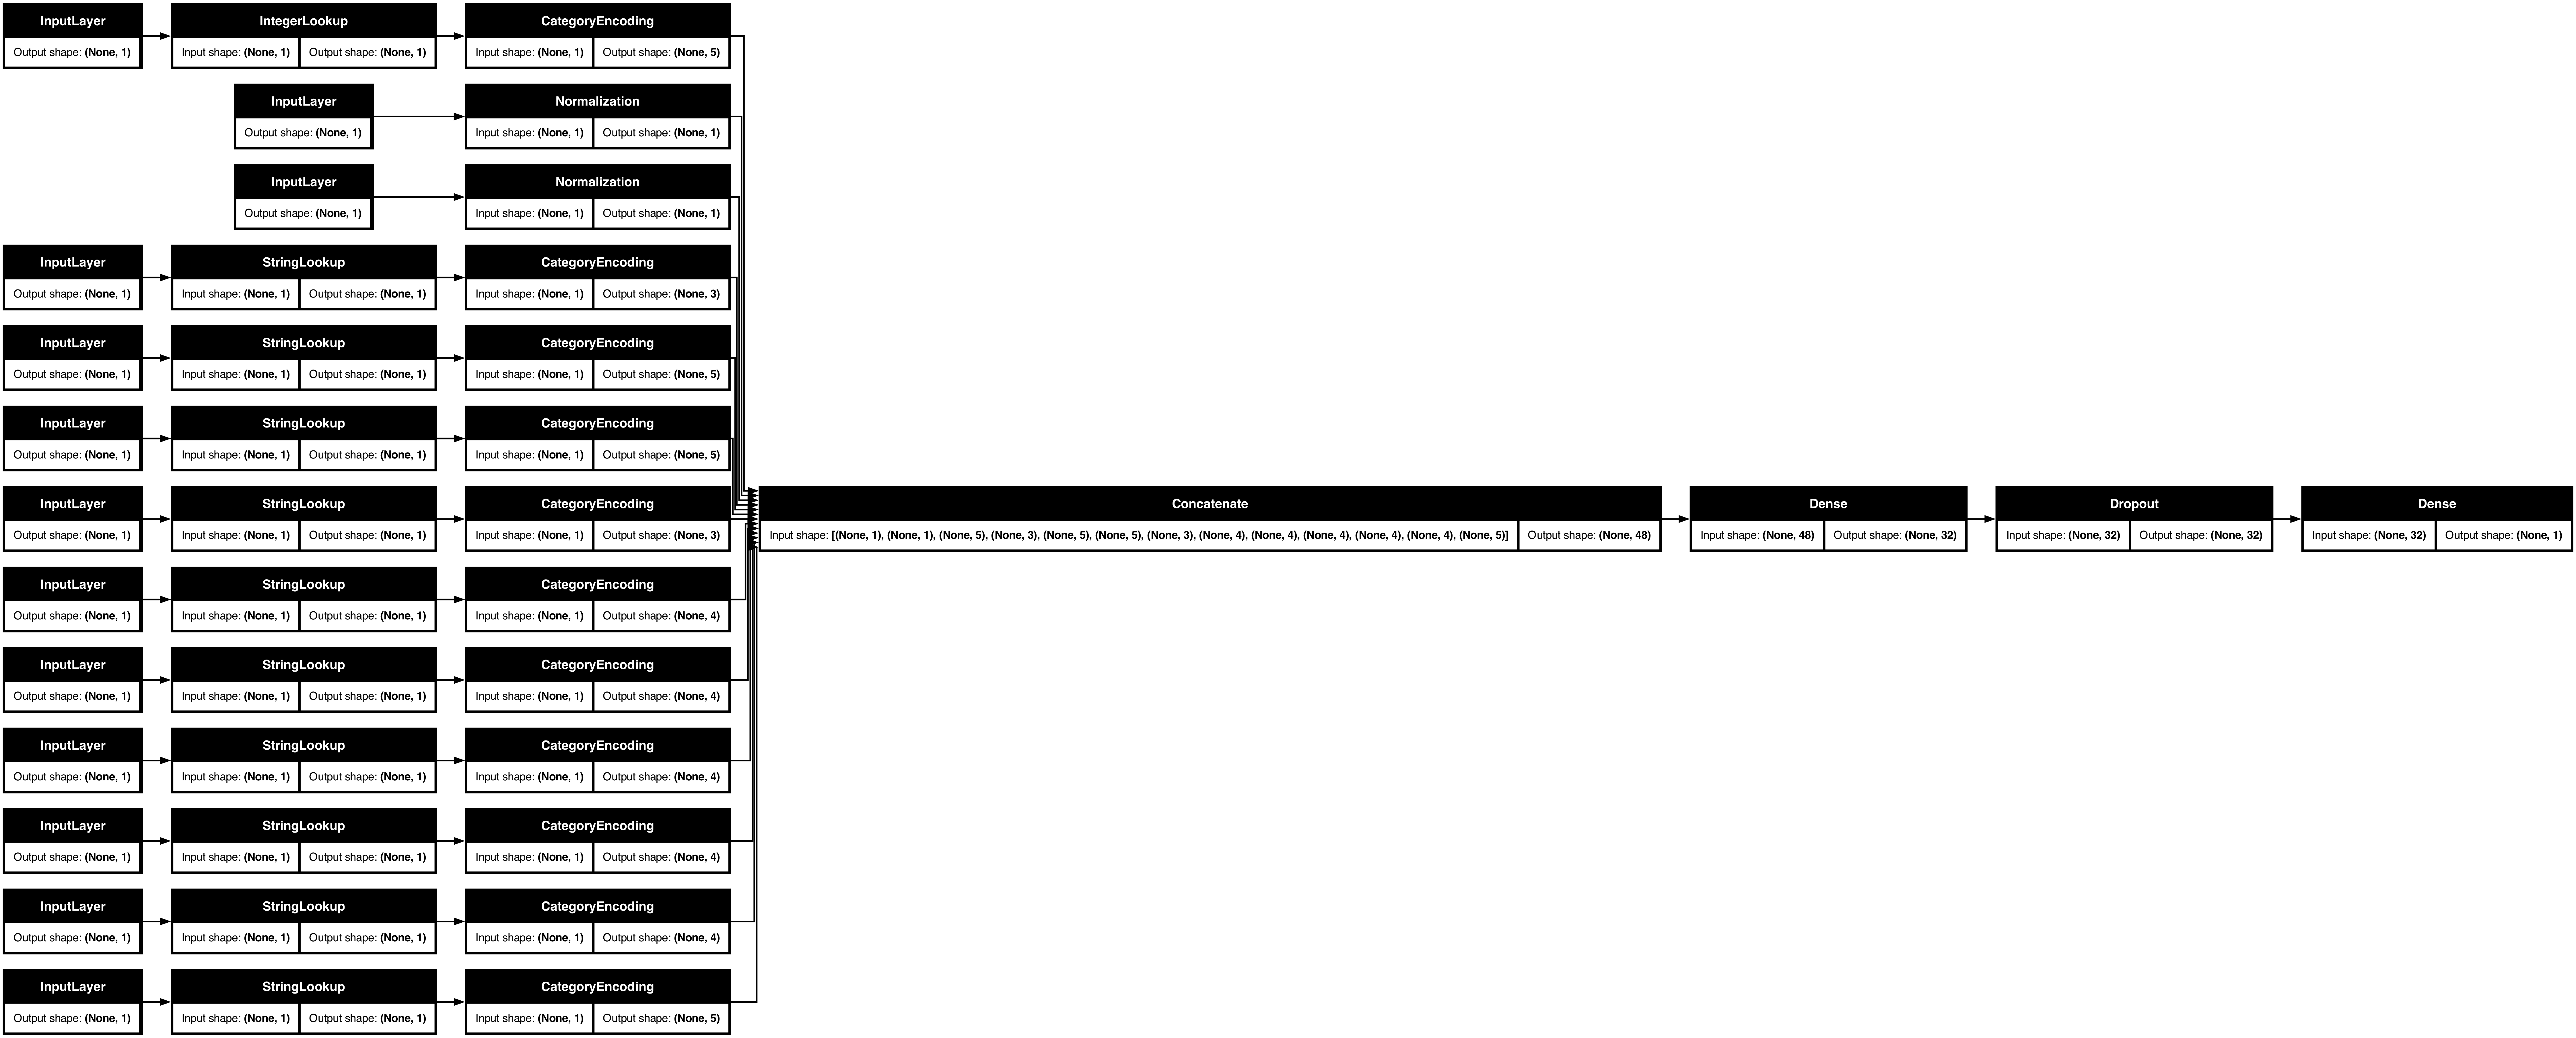

In [205]:
# 모델 생성
all_features = tf.keras.layers.concatenate(encoded_features) # 특징들 한 줄로 길게 합치기
x = tf.keras.layers.Dense(32, activation="relu")(all_features) # relu는 0 이하 다 0으로 퉁침
x = tf.keras.layers.Dropout(0.5)(x)
output = tf.keras.layers.Dense(1)(x) # 딱 하나의 결론을 내려야함, 액티베이션 없음 == 날것의 점수.

model = tf.keras.Model(all_inputs, output)

# 시그모이드를 쓰면 결과가 확률로 나온다. 하지만 from_logits=True이렇게 쓰면 더 정확하게 채점관이 확률로 바꿔 채점함.
# 후자 방법이 에러가 더 적고 정확함.
# 모델 컴파일
model.compile(optimizer='adam',
               loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), # 로봇이 낸 정답과 얼마나 거리가 먼지(Crossentropy), 점수가 날것이니 확률로 바꾸어 채점할것(from_logits=True).
               metrics=["accuracy"]) # 정확도

# 연결 그래프 시각화
tf.keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

In [206]:
# 모델 훈련
training_recode = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6339 - loss: 0.6103 - val_accuracy: 0.7357 - val_loss: 0.5314
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6812 - loss: 0.5768 - val_accuracy: 0.7478 - val_loss: 0.5174
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6903 - loss: 0.5626 - val_accuracy: 0.7574 - val_loss: 0.5112
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6939 - loss: 0.5549 - val_accuracy: 0.7582 - val_loss: 0.5097
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7025 - loss: 0.5526 - val_accuracy: 0.7626 - val_loss: 0.5072
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7076 - loss: 0.5469 - val_accuracy: 0.7634 - val_loss: 0.5056
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7005 - loss: 0.5442 - val_accuracy: 0.7660 - val_loss: 0.5048
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7136 - loss: 0.5377 - val_accuracy: 0.7660 - v

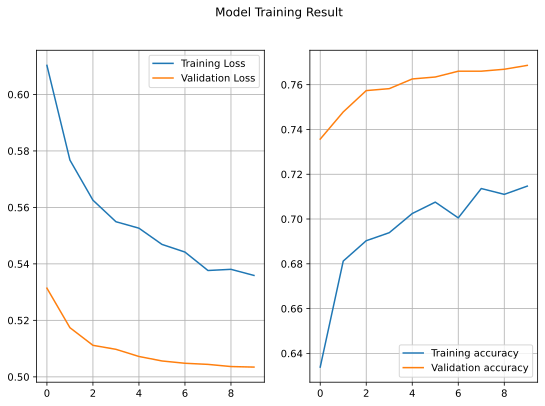

In [207]:
# 학습 곡선 시각화
fig, axes = plt.subplots(ncols=2, figsize=(9,6))
fig.suptitle("Model Training Result")

for idx, ax in enumerate(axes):
    ax.grid()
    if idx == 0:
        ax.plot(training_recode.history["loss"], label="Training Loss")
        ax.plot(training_recode.history["val_loss"], label="Validation Loss")
    else:
        ax.plot(training_recode.history["accuracy"], label="Training accuracy")
        ax.plot(training_recode.history["val_accuracy"], label="Validation accuracy")
    ax.legend()
plt.show()

In [208]:
# 데이터 총개수가 2560개, batch=256 라고 하면 256개씩 10번 돌면 1에포크 완수, 배치한번 수행할 때마다 가중치 업데이트
# 에포크는 전체 복습을 몇번할지 정하는 거임.

# 모델 테스트
loss, accurcay = model.evaluate(test_ds)
print("Loss:", loss)
print("Accurcay:", accurcay)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7548 - loss: 0.5097
Loss: 0.5097343921661377
Accurcay: 0.754766047000885


In [ ]:
# 모델 저장 (왜하지)
model.save('my_pet_classifier.keras')
reloaded_model = tf.keras.models.load_model('my_pet_classifier.keras')


In [241]:
# 추론 수행
sample = {
    'Type': 'Cat',
    'Age': 3,
    'Breed1': 'Tabby',
    'Gender': 'Male',
    'Color1': 'Black',
    'Color2': 'White',
    'MaturitySize': 'Small',
    'FurLength': 'Short',
    'Vaccinated': 'No',
    'Sterilized': 'No',
    'Health': 'Healthy',
    'Fee': 100,
    'PhotoAmt': 2,
}

input_dict = {name: tf.convert_to_tensor([value]) for name, value in sample.items()}
predictions = reloaded_model.predict(input_dict)
prob = tf.nn.sigmoid(predictions[0])

print(
     "이 반려동물이 입양될 확률은 %.1f 프로 입니다." %(100 * prob)
)
print(prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
이 반려동물이 입양될 확률은 80.8 프로 입니다.
tf.Tensor([0.80840135], shape=(1,), dtype=float32)
